# Cryptography - Comparison of Eavesdroppers on Quantum Simulators

In [1]:
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q qiskit_ibm_runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.3 MB/s eta 0:00:00


## Imports

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_aer.noise import NoiseModel, depolarizing_error


In [17]:
N = 200            # Number of BB84 rounds (keep small for Qiskit)
np.random.seed(42)
ATTACK_PROB = 0.5   # Eve attacks 50% of qubits

In [4]:
# Ideal backend
ideal_backend = AerSimulator()
sampler = Sampler(mode=ideal_backend)

# Noise model
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.02, 1),
    ['x', 'h']
)

# Noisy backend
noisy_backend = AerSimulator(noise_model=noise_model)
noisy_sampler = Sampler(mode=noisy_backend)


In [5]:
def prepare_bb84_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)

    if bit == 1:
        qc.x(0)
    if basis == 1:  # X basis
        qc.h(0)

    return qc


In [7]:
def bb84_single_shot(alice_bit, alice_basis, bob_basis):
    qc = prepare_bb84_qubit(alice_bit, alice_basis)

    if bob_basis == 1:
        qc.h(0)

    qc.measure(0, 0)

    job = sampler.run([qc], shots=1)
    result = job.result()
    counts = result[0].data.c.get_counts(0)
    key = next(iter(counts))
    measured_bit=int(key)

    return measured_bit


In [8]:
def bb84_single_shot_noisy(alice_bit, alice_basis, bob_basis):
    qc = prepare_bb84_qubit(alice_bit, alice_basis)

    if bob_basis == 1:
        qc.h(0)

    qc.measure(0, 0)

    job = noisy_sampler.run([qc], shots=1)
    result = job.result()

    counts = result[0].data.c.get_counts(0)
    key = next(iter(counts))
    measured_bit = int(key)

    return measured_bit


## Baseline

In [9]:
def bb84_baseline(noise=False):
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    bob_bases = np.random.randint(0, 2, N)

    bob_results = []

    for i in range(N):
        if noise:
            bob_results.append(
                bb84_single_shot_noisy(
                    alice_bits[i],
                    alice_bases[i],
                    bob_bases[i]
                )
            )
        else:
            bob_results.append(
                bb84_single_shot(
                    alice_bits[i],
                    alice_bases[i],
                    bob_bases[i]
                )
            )

    bob_results = np.array(bob_results)

    mask = alice_bases == bob_bases
    alice_key = alice_bits[mask]
    bob_key = bob_results[mask]

    qber = np.mean(alice_key != bob_key)
    return len(alice_key), qber


## Intercept Resend

In [10]:
def intercept_resend_with_eve_info(noise=False):
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    eve_bases = np.random.randint(0, 2, N)
    bob_bases = np.random.randint(0, 2, N)

    eve_results = []
    bob_results = []

    for i in range(N):
        # Alice → Eve
        if noise:
            eve_bit = bb84_single_shot_noisy(
                alice_bits[i],
                alice_bases[i],
                eve_bases[i]
            )
        else:
            eve_bit = bb84_single_shot(
                alice_bits[i],
                alice_bases[i],
                eve_bases[i]
            )
        eve_results.append(eve_bit)

        # Eve → Bob
        if noise:
            bob_bit = bb84_single_shot_noisy(
                eve_bit,
                eve_bases[i],
                bob_bases[i]
            )
        else:
            bob_bit = bb84_single_shot(
                eve_bit,
                eve_bases[i],
                bob_bases[i]
            )
        bob_results.append(bob_bit)

    eve_results = np.array(eve_results)
    bob_results = np.array(bob_results)

    # Sifting
    mask = alice_bases == bob_bases
    alice_key = alice_bits[mask]
    bob_key = bob_results[mask]
    eve_key = eve_results[mask]

    qber = np.mean(alice_key != bob_key)
    eve_info = np.mean(alice_key == eve_key)

    return len(alice_key), qber, eve_info


In [16]:
def print_result(title, key_len, qber, eve_info=None):
    print(f"\n{title}")
    print(f"  Sifted Key Length : {key_len}")
    print(f"  QBER              : {qber:.5f}")
    if eve_info is not None:
        print(f"  Eve Info          : {eve_info:.5f}")


print("===== QISKIT BB84 — IDEAL CHANNEL =====")

k, q = bb84_baseline(noise=False)
print_result("Baseline (No Eve)", k, q)

k, q, e = intercept_resend(noise=False)
print_result("Intercept–Resend", k, q, e)


print("\n===== QISKIT BB84 — NOISY CHANNEL =====")

k, q = bb84_baseline(noise=True)
print_result("Baseline (No Eve)", k, q)

k, q, e = intercept_resend(noise=True)
print_result("Intercept–Resend", k, q, e)


===== QISKIT BB84 — IDEAL CHANNEL =====

Baseline (No Eve)
  Sifted Key Length : 86
  QBER              : 0.00000

Intercept–Resend
  Sifted Key Length : 94
  QBER              : 0.21277
  Eve Info          : 0.72340

===== QISKIT BB84 — NOISY CHANNEL =====

Baseline (No Eve)
  Sifted Key Length : 96
  QBER              : 0.01042

Intercept–Resend
  Sifted Key Length : 96
  QBER              : 0.28125
  Eve Info          : 0.75000


## Random Basis Attack (Prob =0.5)

In [18]:
def random_basis_attack(noise=False, attack_prob=0.5):
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    eve_bases = np.random.randint(0, 2, N)
    bob_bases = np.random.randint(0, 2, N)

    eve_results = np.full(N, -1)
    bob_results = []

    for i in range(N):
        # Decide whether Eve attacks
        if np.random.rand() < attack_prob:
            # Eve intercepts
            if noise:
                eve_bit = bb84_single_shot_noisy(
                    alice_bits[i],
                    alice_bases[i],
                    eve_bases[i]
                )
            else:
                eve_bit = bb84_single_shot(
                    alice_bits[i],
                    alice_bases[i],
                    eve_bases[i]
                )
            eve_results[i] = eve_bit
            sent_bit = eve_bit
            sent_basis = eve_bases[i]
        else:
            # No attack
            sent_bit = alice_bits[i]
            sent_basis = alice_bases[i]

        # Bob measures
        if noise:
            bob_bit = bb84_single_shot_noisy(
                sent_bit,
                sent_basis,
                bob_bases[i]
            )
        else:
            bob_bit = bb84_single_shot(
                sent_bit,
                sent_basis,
                bob_bases[i]
            )

        bob_results.append(bob_bit)

    bob_results = np.array(bob_results)

    # Sifting
    mask = alice_bases == bob_bases
    alice_key = alice_bits[mask]
    bob_key = bob_results[mask]
    eve_key = eve_results[mask]

    qber = np.mean(alice_key != bob_key)

    # Eve info only where she actually attacked
    valid = eve_key != -1
    eve_info = (
        np.mean(alice_key[valid] == eve_key[valid])
        if np.any(valid)
        else 0.0
    )

    return len(alice_key), qber, eve_info


In [19]:
k, q, e = random_basis_attack(noise=False, attack_prob=0.5)
print("Random-Basis Attack (Ideal)")
print("Key length:", k)
print("QBER:", q)
print("Eve info:", e)

k, q, e = random_basis_attack(noise=True, attack_prob=0.5)
print("\nRandom-Basis Attack (Noisy)")
print("Key length:", k)
print("QBER:", q)
print("Eve info:", e)


Random-Basis Attack (Ideal)
Key length: 95
QBER: 0.11578947368421053
Eve info: 0.7959183673469388

Random-Basis Attack (Noisy)
Key length: 104
QBER: 0.17307692307692307
Eve info: 0.6888888888888889


## Random Basis Attack(Sweep of attack probs)

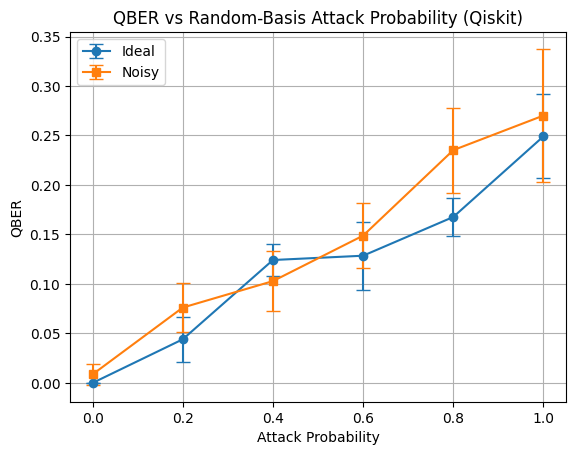

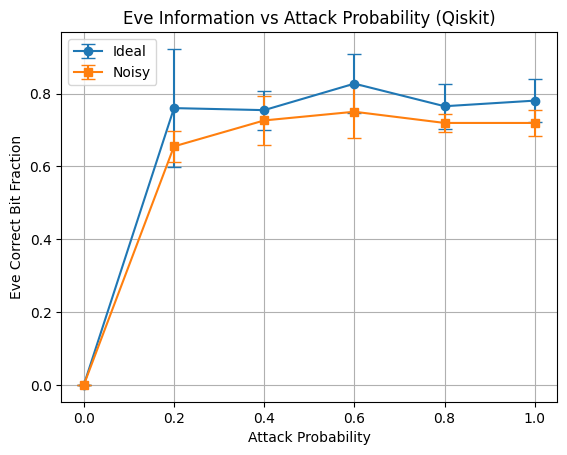

In [23]:
N = 100      # per sweep point
RUNS = 5     # averaging
def sweep_random_basis_qiskit(
    attack_probs,
    runs=5,
    noise=False
):
    qber_means = []
    qber_stds = []
    eve_means = []
    eve_stds = []

    for p in attack_probs:
        qbers = []
        eves = []

        for _ in range(runs):
            _, qber, eve_info = random_basis_attack(
                noise=noise,
                attack_prob=p
            )
            qbers.append(qber)
            eves.append(eve_info)

        qber_means.append(np.mean(qbers))
        qber_stds.append(np.std(qbers))
        eve_means.append(np.mean(eves))
        eve_stds.append(np.std(eves))

    return (
        np.array(qber_means),
        np.array(qber_stds),
        np.array(eve_means),
        np.array(eve_stds)
    )

attack_probs = np.linspace(0, 1, 6)

qber_i, qber_i_std, eve_i, eve_i_std = \
    sweep_random_basis_qiskit(
        attack_probs,
        runs=5,
        noise=False
    )

qber_n, qber_n_std, eve_n, eve_n_std = \
    sweep_random_basis_qiskit(
        attack_probs,
        runs=5,
        noise=True
    )
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(
    attack_probs,
    qber_i,
    yerr=qber_i_std,
    marker='o',
    capsize=5,
    label="Ideal"
)
plt.errorbar(
    attack_probs,
    qber_n,
    yerr=qber_n_std,
    marker='s',
    capsize=5,
    label="Noisy"
)

plt.xlabel("Attack Probability")
plt.ylabel("QBER")
plt.title("QBER vs Random-Basis Attack Probability (Qiskit)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.errorbar(
    attack_probs,
    eve_i,
    yerr=eve_i_std,
    marker='o',
    capsize=5,
    label="Ideal"
)
plt.errorbar(
    attack_probs,
    eve_n,
    yerr=eve_n_std,
    marker='s',
    capsize=5,
    label="Noisy"
)

plt.xlabel("Attack Probability")
plt.ylabel("Eve Correct Bit Fraction")
plt.title("Eve Information vs Attack Probability (Qiskit)")
plt.legend()
plt.grid(True)
plt.show()



## Entanglement-Based Attacks

In [12]:
from qiskit import QuantumCircuit
import numpy as np
N=200
def bb84_entanglement_probe(alice_bit, alice_basis, bob_basis, theta):
    qc = QuantumCircuit(2, 1)  # qubit 0 = Alice, qubit 1 = Eve probe

    # Alice prepares state
    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)

    # Eve entangles probe (controlled rotation)
    qc.cry(theta, 0, 1)

    # Bob measures
    if bob_basis == 1:
        qc.h(0)

    qc.measure(0, 0)

    job = sampler.run([qc], shots=1)
    result = job.result()
    measured_bit = result[0]

    return measured_bit


In [13]:
def entanglement_probe_attack(theta, noise=False):
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    bob_bases = np.random.randint(0, 2, N)

    bob_results = []

    for i in range(N):
        if noise:
            qc = QuantumCircuit(2, 1)

            if alice_bits[i] == 1:
                qc.x(0)
            if alice_bases[i] == 1:
                qc.h(0)

            qc.cry(theta, 0, 1)

            if bob_bases[i] == 1:
                qc.h(0)

            qc.measure(0, 0)

            job = noisy_sampler.run([qc], shots=1)
            result = job.result()
            counts = result[0].data.c.get_counts(0)
            key = next(iter(counts))
            bob_results.append(int(key))
        else:
            bob_results.append(
                bb84_entanglement_probe(
                    alice_bits[i],
                    alice_bases[i],
                    bob_bases[i],
                    theta
                )
            )

    bob_results = np.array(bob_results)

    mask = alice_bases == bob_bases
    alice_key = alice_bits[mask]
    bob_key = bob_results[mask]

    qber = np.mean(alice_key != bob_key)
    return len(alice_key), qber


In [15]:
theta = np.pi / 8  # weak probe

k, q = entanglement_probe_attack(theta, noise=False)
print("Entanglement Probe (Ideal)")
print("Key length:", k)
print("QBER:", q)

k, q = entanglement_probe_attack(theta, noise=True)
print("Entanglement Probe (Noisy)")
print("Key length:", k)
print("QBER:", q)


Entanglement Probe (Ideal)
Key length: 91
QBER: 1.0
Entanglement Probe (Noisy)
Key length: 108
QBER: 0.027777777777777776


## Entanglement Sweep

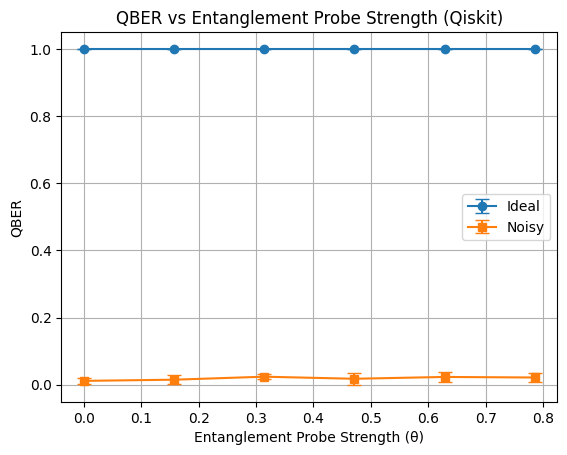

In [21]:
def sweep_entanglement_qiskit(
    thetas,
    runs=5,
    noise=False
):
    qber_means = []
    qber_stds = []

    for theta in thetas:
        qbers = []

        for _ in range(runs):
            _, qber = entanglement_probe_attack(
                theta=theta,
                noise=noise
            )
            qbers.append(qber)

        qber_means.append(np.mean(qbers))
        qber_stds.append(np.std(qbers))

    return np.array(qber_means), np.array(qber_stds)
thetas = np.linspace(0, np.pi/4, 6)

qber_ei, qber_ei_std = sweep_entanglement_qiskit(
    thetas,
    runs=5,
    noise=False
)

qber_en, qber_en_std = sweep_entanglement_qiskit(
    thetas,
    runs=5,
    noise=True
)
plt.figure()
plt.errorbar(
    thetas,
    qber_ei,
    yerr=qber_ei_std,
    marker='o',
    capsize=5,
    label="Ideal"
)
plt.errorbar(
    thetas,
    qber_en,
    yerr=qber_en_std,
    marker='s',
    capsize=5,
    label="Noisy"
)

plt.xlabel("Entanglement Probe Strength (θ)")
plt.ylabel("QBER")
plt.title("QBER vs Entanglement Probe Strength (Qiskit)")
plt.legend()
plt.grid(True)
plt.show()
